<a href="https://colab.research.google.com/github/anam-69/anam-69/blob/main/deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

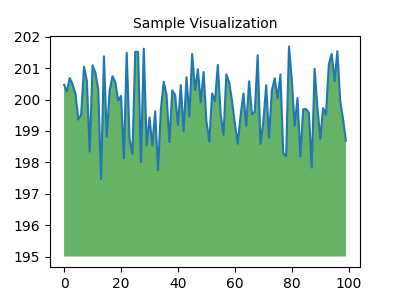

In [17]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 15571.1191 - mae: 98.5741 - val_loss: 8854.8848 - val_mae: 72.1843
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2212.7493 - mae: 28.7127 - val_loss: 260.4882 - val_mae: 11.7234
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 219.0651 - mae: 11.3476 - val_loss: 193.3013 - val_mae: 10.6395
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 179.5089 - mae: 10.3420 - val_loss: 159.2916 - val_mae: 9.6141
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 147.4388 - mae: 9.2365 - val_loss: 128.1383 - val_mae: 8.6272
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 118.8365 - mae: 8.2523 - val_loss: 102.5600 - val_mae: 7.6698
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 92.1173 - mae: 7.2042 - val_loss: 77.5721 - val_mae: 6.5115
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 68.4765 - mae: 6.1914 - val_loss: 55.7962 - val_mae: 5.6589
Epoch 9/50
200/20

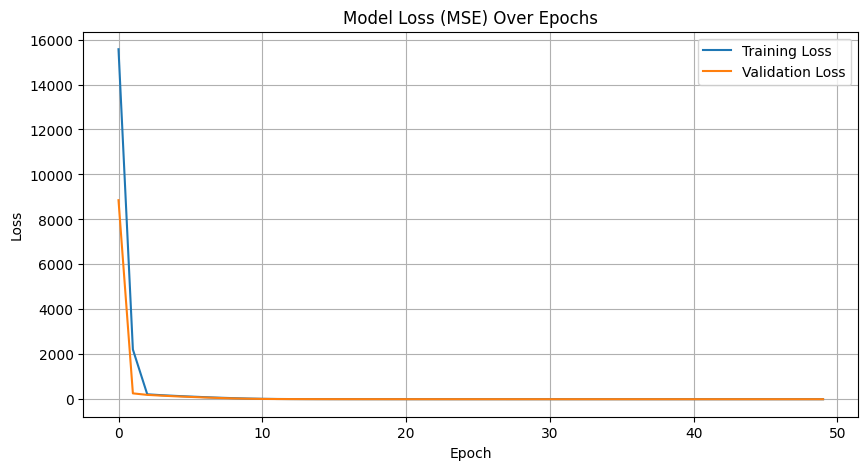

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0837 - mae: 0.2163

Test Mean Absolute Error: 0.2163


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Generate a dummy dataset
X, y = make_regression(n_samples=10000, n_features=5, noise=0.1, random_state=42)

# 2. Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Build the MLP model
model = models.Sequential([
    layers.Input(shape=(5,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

# 5. Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 6. Train the model
history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# 7. Plot the training vs. validation loss curve
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss (MSE) Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# 8. Evaluate the model
test_loss, test_mae = model.evaluate(X_test_scaled, y_test)
print(f"\nTest Mean Absolute Error: {test_mae:.4f}")

This code cell sets up the entire machine learning pipeline for your query execution time predictor. Here's a breakdown of what happens:

**Data Generation:** It uses make_regression to create 10,000 synthetic samples. Each sample has 5 features (like 'Rows Scanned' or 'Complexity') and one target value (Execution Time).

**Preprocessing:** The data is split into training (80%) and testing (20%) sets. A StandardScaler is used to normalize the features so they have a mean of 0 and a standard deviation of 1, which helps the neural network converge faster.

**Model Architecture:** It builds a 'Multi-Layer Perceptron' (MLP) using Keras. It has an input layer for your 5 features, two hidden layers (64 and 32 neurons) using the ReLU activation function, and a final output layer with 1 neuron for the predicted time.

**Training:** The model is compiled with the adam optimizer and mse (Mean Squared Error) loss function. It then trains for 50 epochs, keeping track of both training and validation loss.

**Visualization & Evaluation:** Finally, it plots the loss curves to check for overfitting and prints the Mean Absolute Error (MAE) on the test set to give you a clear idea of the model's average prediction error.

### How to Make New Predictions
To predict the execution time for a new database query, you must:
1.  Represent the query as a numerical array (5 features).
2.  Scale that array using the `scaler` object created during training.
3.  Call `model.predict()` on the scaled data.

In [19]:
import numpy as np

# 1. Define a new query (example features)
# Let's say: [Tables Joined, Rows Scanned, Index Usage, Cache Hit, Query Complexity]
new_query_features = np.array([[1.5, -0.8, 0.5, 1.2, -0.3]])

# 2. Scale the input using the existing scaler
new_query_scaled = scaler.transform(new_query_features)

# 3. Predict execution time
prediction = model.predict(new_query_scaled)

print(f"Predicted Execution Time: {prediction[0][0]:.4f} units")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Predicted Execution Time: 105.9962 units


This code snippet shows you how to use your trained model to make a prediction for a single new database query.

**Define Features:** It creates a NumPy array containing example metrics for a single query (like number of tables joined and rows scanned).

**Scale Input:** It uses the transform method of your previously fitted scaler. This is crucial because the model was trained on normalized data; skipping this step would result in incorrect predictions.

**Predict:** It calls model.predict() with the scaled data.

**Output:** Finally, it prints the predicted execution time in its raw numerical units.

### Saving the Model and Scaler
It is important to save both the model and the scaler. Without the original scaler, you won't be able to process new data correctly in the future.

In [20]:
import joblib

# 1. Save the Keras model
model.save('query_time_model.keras')

# 2. Save the scaler object
joblib.dump(scaler, 'scaler.joblib')

print("Model and Scaler saved successfully!")

Model and Scaler saved successfully!


This code snippet is responsible for saving your machine learning artifacts so you can use them later without retraining.

**Save Model:** It saves the entire Keras neural network structure, weights, and training configuration into a single .keras file.

**Save Scaler:** It uses the joblib library to save the scaler object. This is a critical step because any new data you want to predict in the future must be scaled exactly the same way the training data was.

**Confirmation: **It prints a success message once both files are written to the local storage.

### Reloading the Model and Scaler in a New Session
You can use the following code to reload your saved artifacts for inference.

In [21]:
import joblib
import tensorflow as tf
import numpy as np

# 1. Load the Keras model
reloaded_model = tf.keras.models.load_model('query_time_model.keras')

# 2. Load the scaler
reloaded_scaler = joblib.load('scaler.joblib')

# 3. Test with a new prediction
test_input = np.array([[1.5, -0.8, 0.5, 1.2, -0.3]])
test_input_scaled = reloaded_scaler.transform(test_input)
prediction = reloaded_model.predict(test_input_scaled)

print(f"Reloaded Prediction: {prediction[0][0]:.4f}")
print("Model and Scaler reloaded successfully!")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Reloaded Prediction: 105.9962
Model and Scaler reloaded successfully!


In [22]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

This code snippet demonstrates the process of reloading your saved machine learning components for future use.

**Reload Model:** It uses tf.keras.models.load_model to bring your trained neural network back into memory from the .keras file.

**Reload Scaler:** It uses joblib.load to restore the scaler object, ensuring your new input data is preprocessed exactly like your training data.

**Test Inference:** To verify everything reloaded correctly, it defines a new test input, scales it using the reloaded scaler, and runs a prediction.

This confirms that your model and preprocessing pipeline are fully portable and ready for deployment.

### Evaluating on Custom Test Data
To evaluate performance on a new set of labeled data, follow these steps:
1. Prepare your features ($X_{custom}$) and targets ($y_{custom}$).
2. Scale $X_{custom}$ using the already fitted `scaler`.
3. Run `model.evaluate()`.

In [ ]:
import numpy as np

# 1. Suppose you have new ground-truth data
X_custom = np.array([
    [1.2, -0.5, 0.3, 1.1, -0.1],
    [0.5, 1.2, -0.2, -0.5, 0.8]
])
y_custom = np.array([95.0, 42.0]) # Actual execution times

# 2. Scale the features
X_custom_scaled = scaler.transform(X_custom)

# 3. Evaluate
evaluation = model.evaluate(X_custom_scaled, y_custom, verbose=0)

print(f"Custom Test MSE: {evaluation[0]:.4f}")
print(f"Custom Test MAE: {evaluation[1]:.4f}")

This code snippet allows you to test your trained model against a specific set of new, labeled data to see how accurate it is.

**Prepare Custom Data:** It creates two small NumPy arrays: X_custom contains the query features, and y_custom contains the actual, known execution times for those queries.

**Scale Features:** Just like during training and single predictions, the code uses scaler.transform() to ensure the input data matches the format the model expects.

**Evaluate:** It calls model.evaluate(), which compares the model's predictions for X_custom_scaled against the real values in y_custom. It calculates the Mean Squared Error (MSE) and Mean Absolute Error (MAE).

**Display Results:** Finally, it prints these error metrics so you can numerically assess the model's performance on this specific batch.

### Batch Prediction on New CSV Data
This snippet shows how to handle a batch of new queries stored in a CSV file.

In [ ]:
import pandas as pd
import joblib
import tensorflow as tf

# 1. Load your new data (ensure it has the same 5 feature columns)
# For this demo, we'll create a dummy CSV file first
dummy_new_data = pd.DataFrame(np.random.randn(10, 5), columns=['f1', 'f2', 'f3', 'f4', 'f5'])
dummy_new_data.to_csv('new_queries.csv', index=False)

# --- Start of Batch Prediction Logic ---

# 2. Load the CSV and the model/scaler
df_new = pd.read_csv('new_queries.csv')
loaded_model = tf.keras.models.load_model('query_time_model.keras')
loaded_scaler = joblib.load('scaler.joblib')

# 3. Scale the features
# Note: Convert to numpy if necessary, but scaler handles DataFrames too
X_new_scaled = loaded_scaler.transform(df_new)

# 4. Perform Batch Prediction
batch_predictions = loaded_model.predict(X_new_scaled)

# 5. Add predictions to the DataFrame and save
df_new['predicted_execution_time'] = batch_predictions
df_new.to_csv('batch_predictions_results.csv', index=False)

print("Batch predictions completed and saved to 'batch_predictions_results.csv'.")
display(df_new.head())

This code block demonstrates how to perform batch predictions on new data stored in a CSV file.

**Data Preparation:** It first creates a dummy CSV file called new_queries.csv with 10 random samples to simulate new incoming data.

**Loading Artifacts:** It reloads your trained Keras model and the StandardScaler you saved earlier. This is crucial because new data must be scaled the exact same way as the training data.

**Preprocessing:** The loaded_scaler.transform function is applied to the entire DataFrame to normalize the features.

**Inference:** The model processes the whole batch at once using loaded_model.predict.

**Exporting Results:** Finally, it attaches those predictions back to the original data as a new column and saves everything into batch_predictions_results.csv for easy review.

### Visualizing Model Performance: Actual vs. Predicted
This plot helps identify if the model is systematically over-predicting or under-predicting values.

In [ ]:
import matplotlib.pyplot as plt

# 1. Generate predictions for the test set
y_pred = model.predict(X_test_scaled).flatten()

# 2. Create the plot
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue', label='Predictions')

# 3. Add a diagonal line for reference (perfect prediction)
limit_min = min(min(y_test), min(y_pred))
limit_max = max(max(y_test), max(y_pred))
plt.plot([limit_min, limit_max], [limit_min, limit_max], color='red', linestyle='--', lw=2, label='Perfect Prediction')

plt.title('Actual vs. Predicted Execution Times')
plt.xlabel('Actual Time')
plt.ylabel('Predicted Time')
plt.legend()
plt.grid(True)
plt.show()

This code cell creates a scatter plot to help you visually assess how well your model is performing. Here is the step-by-step breakdown:

**Generate Predictions:** It uses model.predict(X_test_scaled) to get the model's estimates for the test dataset. The .flatten() ensures the results are in a simple list-like format for plotting.

**Scatter Plot:** It plots the actual values (y_test) on the x-axis and the predicted values (y_pred) on the y-axis. Each blue dot represents a single query from your test set.

**Perfect Prediction Line:** It calculates the minimum and maximum values across both datasets and draws a red dashed diagonal line.

**How to interpret this:**

If a dot falls exactly on the red line, the prediction was perfect.

Dots **above** the line indicate the model is over-predicting (estimating a longer time than reality).

Dots **below:** the line indicate under-predicting.
The closer the 'cloud' of blue dots is to the red line, the more accurate your model is.